# Airbnb NYC Dataset – Data Understanding & Assessment

## Project Objective
To analyze Airbnb listings in New York City, assess data quality, clean the dataset, and uncover actionable business insights related to pricing, availability, host behavior, and customer engagement. This objective aligns well with the analyses we'll perform throughout the project.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/AB_NYC_2019.csv')

# Dataset Information
This dataset contains information about Airbnb listings in New York City, including details about the listings, hosts, locations, pricing, availability, and customer reviews. It provides valuable insights into the Airbnb rental market and can be used to analyze pricing trends, host activity, room types, neighborhood popularity, and booking patterns. The dataset is suitable for exploratory data analysis (EDA), data cleaning, and deriving business insights to support data-driven decision-making.

# Column Description
- **id** - Unique identifier for each Airbnb listing
- **name** - Title of the listing
- **host_id** - Unique identifier for the host
- **host_name** - Name of the host
- **neighbourhood_group** - Borough where the listing is located
- **neighbourhood** - Specific neighbourhood of the listing
- **latitude** - Latitude coordinate
- **longitude** - Longitude coordinate
- **room_type** - Type of accommodation offered
- **price** - Price per night
- **minimum_nights** - Minimum number of nights required for booking
- **number_of_reviews** - Total number of reviews received
- **last_review** - Date of the most recent review
- **reviews_per_month** - Average number of reviews received per month
- **calculated_host_listings_count** - Number of listings owned by the host
- **availability_365** - Number of days the listing is available in a year

# Initial Dataset Exploration

## Size of the dataset

In [ ]:
df.shape

(48895, 16)

## Data Types & Missing Values
- 16 missing values found in col - `name`
- 21 missing values found in col - `host_name`
- 10052 missing values found in col - `last_review`
- 10052 missing values found in col - `reviews_per_month`

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## Number of duplicate records in the dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

## Summary statistics

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**Observation**
- The dataset contains 9 numerical columns, providing information about listing IDs, host IDs, geographical coordinates, pricing, booking requirements, reviews, host activity, and availability.
- The `price` ranges from 0 to 10,000. A minimum price of 0 and an extremely high maximum price of 10,000 appear unusual and should be investigated during the data quality assessment.
- The `minimum_nights` ranges from 1 to 1,250 nights. Requiring a stay of over three years is highly unusual and may represent an outlier or a special listing.
- The `number_of_reviews` ranges from 0 to 629, indicating that while some listings have never been reviewed, others have received a large number of reviews.
- The `reviews_per_month` ranges from 0.01 to 58.5, suggesting considerable variation in review activity across listings.
- The `calculated_host_listings_count` ranges from 1 to 327, indicating that while many hosts own a single property, some manage a large number of listings.
- The `availability_365` ranges from 0 to 365, which is expected since it represents the number of days a listing is available in a year.
The latitude and longitude values fall within the expected range for New York City and do not immediately indicate any anomalies.

# Data Quality Assessment

## id Assessment
**Conclusion**
- The id column serves as a unique identifier for each Airbnb listing. No data quality issues were identified, and no cleaning is required.

In [ ]:
df['id'].duplicated().sum()

np.int64(0)

In [ ]:
df[df['id']<0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


## name Assessment
**Conclusion**
- The name column is largely of good quality.
- It contains a small number of missing values and four listings with numeric-only titles, which may require further review during the cleaning phase.
- Variations in capitalization, language, and punctuation are expected for user-generated listing titles and do not require cleaning.

In [ ]:
df['name'].sample(10)

,name
2990,Cozy Room in Astoria
16910,"Spacious, Affordable 1BR Apartment in Brooklyn"
25012,Williamsburg Bedroom w/Private Terrace!
31848,The Best location in Upper East Side!
47930,"Amazing Bedroom , two stops from Times Square!..."
33582,Private Bedroom in Manhattan
16494,Designer Apartment - Sunny and spacious 1 bedroom
31098,Sunny Studio Williamsburg w/ Private Bath&Entr...
12704,Private room in spacious apartment
2350,Stylish Arty Brooklyn Appartment #4


In [ ]:
df[df['name'].str.isupper().fillna(False)]['name']

/tmp/ipykernel_560/571798335.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df['name'].str.isupper().fillna(False)]['name']


,name
2,THE VILLAGE OF HARLEM....NEW YORK !
28,"SPACIOUS, LOVELY FURNISHED MANHATTAN BEDROOM"
44,BEST BET IN HARLEM
52,* ORIGINAL BROOKLYN LOFT *
73,"HARLEM, NEW YORK WELCOMES YOU!!"
...,...
48830,"LUXURY, PRIVATE APT ACROSS FROM EMPIRE STATE"
48832,FLATBUSH HANG OUT AND GO
48842,LUXURY MANHATTAN PENTHOUSE+HUDSON RIVER+EMPIRE...
48871,A LARGE ROOM - 1 MONTH MINIMUM - WASHER&DRYER


In [ ]:
df[df['name'].str.isnumeric().fillna(False)]['name']

/tmp/ipykernel_560/45127142.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df['name'].str.isnumeric().fillna(False)]['name']


,name
5276,3
5277,2
29848,1
41525,86


In [ ]:
df['name'].shape

(48895,)

In [ ]:
df['name'].value_counts()

,count
name,
Hillside Hotel,18
Home away from home,17
New york Multi-unit building,16
Brooklyn Apartment,12
Private Room,11
...,...
Spacious Modern Alcove Studio in a Luxury Building,1
Artist's Room in Large Apartment,1
Modern Oasis in Central Park Slope,1


## host_id Assessment
**Conclusion**
- The host_id column serves as a unique identifier for Airbnb hosts.
- No missing or invalid values were found, and the data type is appropriate.
- Duplicate host_id values are expected because a single host can own multiple listings.
- Therefore, no data cleaning is required for this column.

In [ ]:
df[df['host_id'] <= 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


## host_name Assessment
**Conclusion**
- The host_name column is generally of good quality and has the appropriate data type (object).
- It contains 21 missing values, which will be investigated during the data cleaning phase.
- A few records have numeric-only host names, which appear to be potential data entry anomalies and should also be reviewed during cleaning.
- No empty or whitespace-only values were found. Variations in naming conventions, including initials, multiple host names, special characters, and names in different languages, are expected for user-generated data and do not require cleaning.

In [ ]:
df[df['host_name'].str.isnumeric().fillna(False)]['host_name']

/tmp/ipykernel_560/2425565567.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df['host_name'].str.isnumeric().fillna(False)]['host_name']


,host_name
37645,七
38828,475
39254,475
39255,475
39425,475
39433,0123
46588,371


In [ ]:
df[df['host_name'].str.isupper().fillna(False)]['host_name']

/tmp/ipykernel_560/3318589672.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df['host_name'].str.isupper().fillna(False)]['host_name']


,host_name
62,D
219,S.M.
222,I
223,R
315,G & S
...,...
47746,P
47822,H.
47922,J
48654,K


In [ ]:
df[df['host_name'].str.strip() == '']

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


## neighbourhood_group Assessment
**Conclusion**
- The neighbourhood_group column is of good quality and contains five valid boroughs of New York City.
- No missing values, spelling inconsistencies, or invalid categories were identified.
- Therefore, no data cleaning is required for this column.
- The neighbourhood_group column contains only five distinct categories. Since it is a categorical feature with a limited number of unique values, it is a suitable candidate for conversion from the object data type to the category data type during the data cleaning phase to improve memory efficiency.

In [ ]:
df['neighbourhood_group'].dtype

dtype('O')

In [ ]:
df['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


## neighbourhood Assessment
**Conclusion**
- The neighbourhood column is of good quality and contains 221 unique neighbourhoods within New York City.
- No missing values, empty or whitespace-only entries, placeholder values (e.g., "Unknown" or "None"), or obvious spelling inconsistencies were identified.
- The neighbourhood names appear to be valid and consistently formatted.
- Since this column contains a limited number of repeated categorical values, it is a suitable candidate for conversion from the object data type to the category data type during the data cleaning phase to improve memory efficiency.

In [ ]:
df[
    (df['neighbourhood'].str.strip() == '') |
    (df['neighbourhood'].isin(['Unknown', 'None']))
]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [ ]:
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [ ]:
df['neighbourhood'].nunique()

221

## latitude Assessment
**Conclusion**
- The latitude column is of good quality and has the appropriate numeric data type (float64).
- No missing values or invalid latitude values were identified.
- All records fall within the valid global latitude range as well as the approximate geographic boundaries of New York City, indicating that the coordinate data is consistent and reliable.
- Therefore, no data cleaning is required for this column.

In [ ]:
# Approximate latitude range of New York City: 40.496°N to 40.915°N

df[(df['latitude']>40.496) & (df['latitude']<40.915)].shape

(48895, 16)

## longitude Assessment
**Conclusion**
- The longitude column is of good quality and has the appropriate numeric data type (float64).
- No missing values or invalid longitude values were identified.
- All longitude values fall within both the valid global longitude range and the approximate geographic boundaries of New York City, indicating that the location coordinates are consistent and reliable.
- Therefore, no data cleaning is required for this column.

In [ ]:
# Approximate longitude range of New York City: 74.2591°W to 73.7004°W

df[(df['longitude']>-74.2599) & (df['longitude']<-73.7004)].shape

(48895, 16)

## room_type Assessment
**Conclusion**
- The room_type column is of good quality and contains three valid Airbnb room categories: Entire home/apt, Private room, and Shared room.
- No missing values, invalid categories, or spelling inconsistencies were identified.
- Since the column contains a small number of repeated categorical values, it is an ideal candidate for conversion from the object data type to the category data type during the data cleaning phase to improve memory efficiency.

In [ ]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


## price Assessment
**Conclusion**
- The price column is generally of good quality and has the appropriate numeric data type (int64).
- No missing values or negative prices were found. However, 11 listings have a price of 0, which is unlikely for a paid accommodation platform and should be investigated during the data cleaning phase.
- The price distribution is highly right-skewed, with most listings concentrated at lower price ranges.
- The IQR method identified 2,972 potential upper outliers, including listings priced as high as 10,000.
- These values may represent genuine luxury accommodations rather than data errors and should therefore be evaluated carefully before any outlier treatment is applied.

In [ ]:
df[df['price']<=0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [ ]:
df[df['price']<=0].shape[0]

11

In [ ]:
df[df['price']==df['price'].max()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83


<Axes: ylabel='Frequency'>

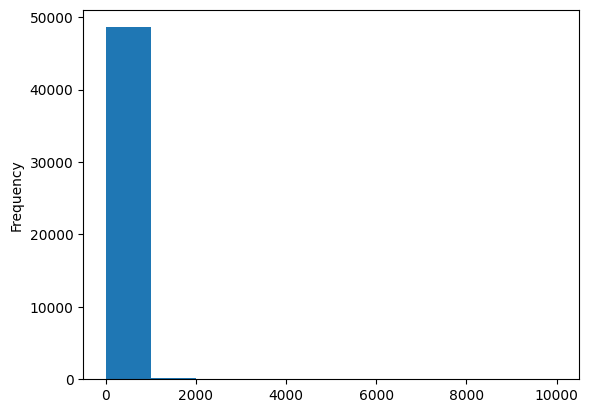

In [ ]:
df['price'].plot(kind='hist')

<Axes: >

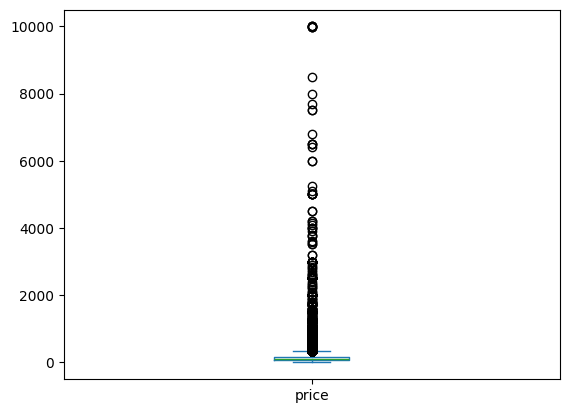

In [ ]:
df['price'].plot(kind='box')

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f'Q1 = {Q1}')
print(f'Q3 = {Q3}')
print(f'IQR = {IQR}')
print(f'Lower Bound = {lower_bound}')
print(f'Upper Bound = {upper_bound}')

print(f'Lower Outliers = {df[df["price"] < lower_bound].shape[0]}')
print(f'Upper Outliers = {df[df["price"] > upper_bound].shape[0]}')

Q1 = 69.0
Q3 = 175.0
IQR = 106.0
Lower Bound = -90.0
Upper Bound = 334.0
Lower Outliers = 0
Upper Outliers = 2972


## minimum_nights Assessment
**Conclusion**
- The minimum_nights column is of good quality and has the appropriate numeric data type (int64).
- No missing values or invalid values (zero or negative minimum stay requirements) were identified.
- The minimum stay ranges from 1 to 1,250 nights, with the maximum value representing a potential long-term rental rather than necessarily a data entry error.
- The distribution is highly right-skewed, and the IQR method identified 6,607 potential upper outliers.
- Given the nature of Airbnb listings, these values may correspond to legitimate long-term accommodations and should therefore be reviewed carefully before deciding on any outlier treatment.
- Unlike the price column, unusually high values in minimum_nights may intentionally reflect long-term rental policies rather than anomalies.

In [ ]:
df[df['minimum_nights']<=0].shape[0]

0

In [ ]:
df['minimum_nights'].describe()

,minimum_nights
count,48895.000000
mean,7.029962
std,20.510550
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1250.000000


In [ ]:
df['minimum_nights'].unique()

array([   1,    3,   10,   45,    2,    5,    4,   90,    7,   14,   60,
         29,   30,  180,    9,   31,    6,   15,    8,   26,   28,  200,
         50,   17,   21,   11,   25,   13,   35,   27,   18,   20,   40,
         44,   65,   55,  120,  365,  122,   19,  240,   88,  115,  150,
        370,   16,   80,  181,  265,  300,   59,  185,  360,   56,   12,
         70,   39,   24,   32, 1000,  110,  270,   22,   75,  250,   62,
         23, 1250,  364,   74,  198,  100,  500,   43,   91,  480,   53,
         99,  160,   47,  999,  186,  366,   68,   93,   87,  183,  299,
        175,   98,  133,  354,   42,   33,   37,  225,  400,  105,  184,
        153,  134,  222,   58,  210,  275,  182,  114,   85,   36])

In [ ]:
df[df['minimum_nights'] == df['minimum_nights'].max()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
5767,4204302,Prime W. Village location 1 bdrm,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180,1250,2,2014-11-09,0.03,1,365


In [ ]:
df[df['minimum_nights'] == df['minimum_nights'].min()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188
17,7322,Chelsea Perfect,18946,Doti,Manhattan,Chelsea,40.74192,-73.99501,Private room,140,1,260,2019-07-01,2.12,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48878,36479723,Room for rest,41326856,Jeerathinan,Queens,Elmhurst,40.74477,-73.87727,Private room,45,1,0,NaN,NaN,5,172
48880,36481315,The Raccoon Artist Studio in Williamsburg New ...,208514239,Melki,Brooklyn,Williamsburg,40.71232,-73.94220,Entire home/apt,120,1,0,NaN,NaN,3,365
48887,36483152,Garden Jewel Apartment in Williamsburg New York,208514239,Melki,Brooklyn,Williamsburg,40.71232,-73.94220,Entire home/apt,170,1,0,NaN,NaN,3,365
48889,36484363,QUIT PRIVATE HOUSE,107716952,Michael,Queens,Jamaica,40.69137,-73.80844,Private room,65,1,0,NaN,NaN,2,163


<Axes: ylabel='Frequency'>

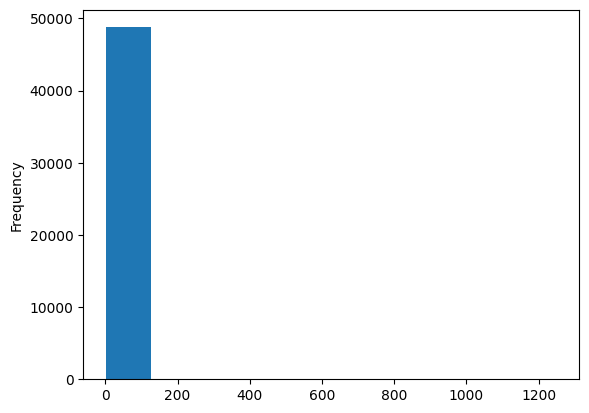

In [ ]:
df['minimum_nights'].plot(kind='hist')

<Axes: >

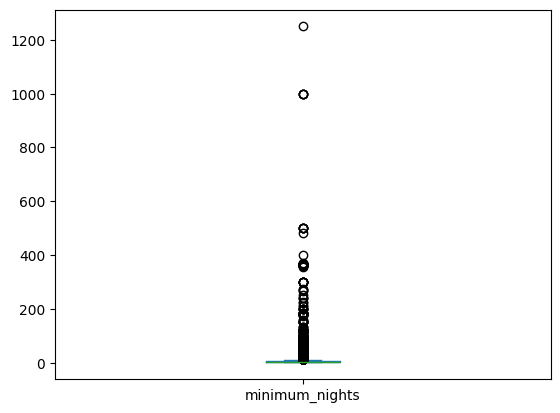

In [ ]:
df['minimum_nights'].plot(kind='box')

In [ ]:
Q1 = df['minimum_nights'].quantile(0.25)
Q3 = df['minimum_nights'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f'Q1 = {Q1}')
print(f'Q3 = {Q3}')
print(f'IQR = {IQR}')
print(f'Lower Bound = {lower_bound}')
print(f'Upper Bound = {upper_bound}')

print(f'Lower Outliers = {df[df["minimum_nights"] < lower_bound].shape[0]}')
print(f'Upper Outliers = {df[df["minimum_nights"] > upper_bound].shape[0]}')

Q1 = 1.0
Q3 = 5.0
IQR = 4.0
Lower Bound = -5.0
Upper Bound = 11.0
Lower Outliers = 0
Upper Outliers = 6607


## number_of_reviews Assessment
**Conclusion**
- The number_of_reviews column is of good quality and has the appropriate numeric data type (int64).
- No missing values or invalid values (negative review counts) were identified.
The number of reviews ranges from 0 to 629, where a value of 0 is valid for new or unrated listings, and the maximum value represents a highly popular listing rather than a data quality issue.
- The distribution is highly right-skewed, and the IQR method identified 6,021 potential upper outliers.
- These values are expected in the Airbnb domain, as popular and long-standing listings naturally accumulate a large number of reviews.
- Therefore, no data cleaning is required for this column.


In [ ]:
df['number_of_reviews'].describe()

,number_of_reviews
count,48895.000000
mean,23.274466
std,44.550582
min,0.000000
25%,1.000000
50%,5.000000
75%,24.000000
max,629.000000


<Axes: ylabel='Frequency'>

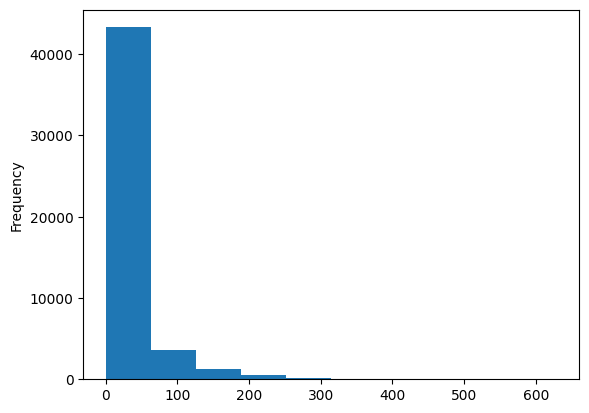

In [ ]:
df['number_of_reviews'].plot(kind='hist')

In [ ]:
df[df['number_of_reviews']==df['number_of_reviews'].max()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
11759,9145202,Room near JFK Queen Bed,47621202,Dona,Queens,Jamaica,40.6673,-73.76831,Private room,47,1,629,2019-07-05,14.58,2,333


<Axes: >

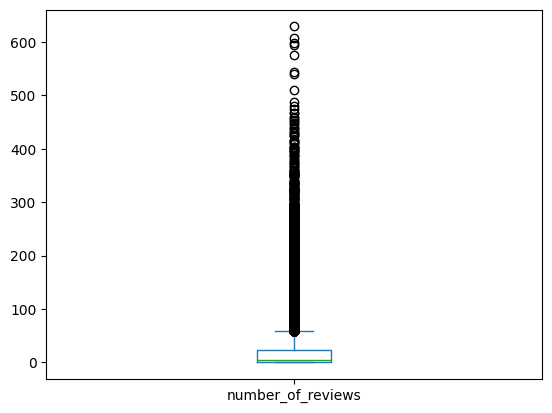

In [ ]:
df['number_of_reviews'].plot(kind='box')

In [ ]:
Q1 = df['number_of_reviews'].quantile(0.25)
Q3 = df['number_of_reviews'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f'Q1 = {Q1}')
print(f'Q3 = {Q3}')
print(f'IQR = {IQR}')
print(f'Lower Bound = {lower_bound}')
print(f'Upper Bound = {upper_bound}')

print(f'Lower Outliers = {df[df["number_of_reviews"] < lower_bound].shape[0]}')
print(f'Upper Outliers = {df[df["number_of_reviews"] > upper_bound].shape[0]}')

Q1 = 1.0
Q3 = 24.0
IQR = 23.0
Lower Bound = -33.5
Upper Bound = 58.5
Lower Outliers = 0
Upper Outliers = 6021


## last_review Assessment
**Conclusion**
- The last_review column is currently stored as an object data type but was successfully converted to datetime64[ns], confirming that all non-missing values are in a valid date format.
- The review dates range from 2011-03-28 to 2019-07-08, which is consistent with the dataset.
- Although the column contains 10,052 missing values, further investigation confirmed that every missing value belongs to a listing with number_of_reviews = 0, while no listings with reviews have a missing last_review.
- Therefore, these missing values are expected and do not represent a data quality issue.
- During the data cleaning phase, the column should be converted to the datetime data type, while the missing values should be retained as they accurately indicate listings that have not yet received any reviews.

In [ ]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [ ]:
df['last_review'].dtype

dtype('<M8[ns]')

In [ ]:
df[df['last_review'].isnull()].shape[0]

10052

In [ ]:
df[(df['last_review'].isnull()) & (df['number_of_reviews']==0)].shape[0]

10052

In [ ]:
df[(df['number_of_reviews'] > 0) & (df['last_review'].isnull())].shape[0]

0

In [ ]:
df['last_review'].max()

Timestamp('2019-07-08 00:00:00')

In [ ]:
df['last_review'].min()

Timestamp('2011-03-28 00:00:00')

## reviews_per_month Assessment
**Conclusion**
- The reviews_per_month column has the appropriate numeric data type (float64) for storing the average number of reviews received per month.
- Although the column contains 10,052 missing values, further investigation confirmed that all missing values correspond to listings with number_of_reviews = 0, while no listings with one or more reviews have missing values.
- Additionally, no zero or negative values were found among the non-missing records, indicating that all calculated monthly review rates are valid.
- Therefore, the missing values are expected and do not represent a data quality issue.
- During the data cleaning phase, these missing values should be retained, as they correctly indicate listings that have not yet received any reviews.

In [ ]:
df['reviews_per_month'].dtype

dtype('float64')

In [ ]:
df['reviews_per_month'].sample(5)

,reviews_per_month
30096,0.30
9320,NaN
4876,0.84
15069,0.08
21385,0.97


In [ ]:
df['reviews_per_month'].isnull().sum()

np.int64(10052)

In [ ]:
df[(df['number_of_reviews']==0) & (df['reviews_per_month'].isnull())].shape[0]

10052

In [ ]:
df[(df['number_of_reviews'] > 0) & (df['reviews_per_month'].isnull())].shape[0]

0

In [ ]:
df[df['reviews_per_month']<=0].shape[0]

0

## calculated_host_listings_count Assessment
**Conclusion**
- The calculated_host_listings_count column has the appropriate numeric data type (int64) and contains no missing, zero, or negative values.
- The number of listings managed by a host ranges from 1 to 327, with the majority of hosts managing only one or two listings.
- The maximum value of 327 belongs to a single host, indicating the presence of a professional host or property management company rather than a data quality issue.
- The distribution is highly right-skewed, and the IQR method identified 7,081 potential upper outliers.
- These outliers are expected because Airbnb permits hosts to manage multiple properties.
- Therefore, no data cleaning is required for this column.

In [ ]:
df['calculated_host_listings_count']

,calculated_host_listings_count
0,6
1,2
2,1
3,1
4,1
...,...
48890,2
48891,2
48892,1
48893,6


In [ ]:
df[df['calculated_host_listings_count']<=0].shape[0]

0

In [ ]:
df[df['calculated_host_listings_count']==df['calculated_host_listings_count'].max()].shape[0]

327

In [ ]:
df[df['calculated_host_listings_count']==df['calculated_host_listings_count'].min()].shape[0]

32303

<Axes: ylabel='Frequency'>

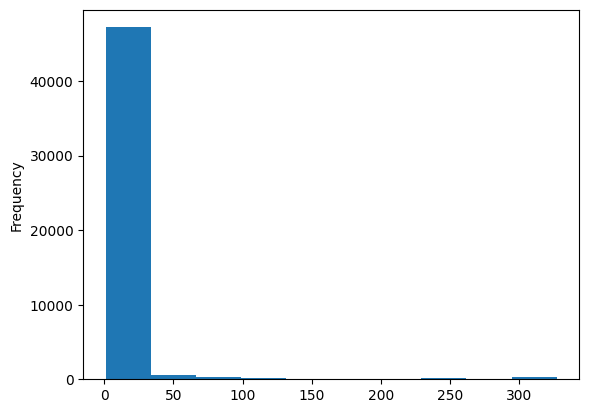

In [ ]:
df['calculated_host_listings_count'].plot(kind='hist')

<Axes: >

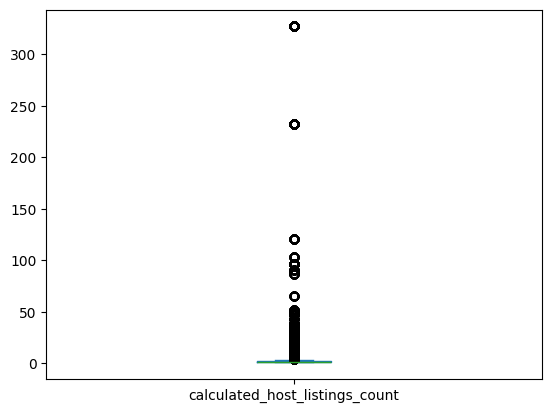

In [ ]:
df['calculated_host_listings_count'].plot(kind='box')

In [ ]:
Q1 = df['calculated_host_listings_count'].quantile(0.25)
Q3 = df['calculated_host_listings_count'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f'Q1 = {Q1}')
print(f'Q3 = {Q3}')
print(f'IQR = {IQR}')
print(f'Lower Bound = {lower_bound}')
print(f'Upper Bound = {upper_bound}')

print(f'Lower Outliers = {df[df["calculated_host_listings_count"] < lower_bound].shape[0]}')
print(f'Upper Outliers = {df[df["calculated_host_listings_count"] > upper_bound].shape[0]}')

Q1 = 1.0
Q3 = 2.0
IQR = 1.0
Lower Bound = -0.5
Upper Bound = 3.5
Lower Outliers = 0
Upper Outliers = 7081


In [ ]:
df[(df['calculated_host_listings_count']==df['calculated_host_listings_count'].max()) & (df['host_id']==219517861)].shape[0]

327

## availability_365 Assessment
**Conclusion**
- The availability_365 column has the appropriate numeric data type (int64) and contains no missing or negative values.
- All values fall within the valid business range of 0 to 365 days, where 0 indicates listings that are unavailable for booking during the year and 365 indicates listings that are available throughout the year.
- The distribution shows concentrations at both extremes, reflecting different hosting and booking strategies.
- Furthermore, the IQR analysis identified no statistical outliers, indicating that all values fall within the expected range.
- Therefore, no data cleaning is required for this column.

In [ ]:
df[df['availability_365']<0].shape[0]

0

In [ ]:
df[df['availability_365']==0].shape[0]

17533

In [ ]:
df['availability_365'].max()

365

In [ ]:
df['availability_365'].min()

0

<Axes: ylabel='Frequency'>

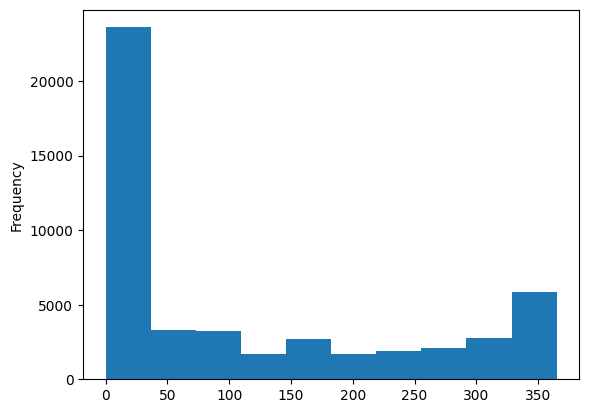

In [ ]:
df['availability_365'].plot(kind='hist')

<Axes: >

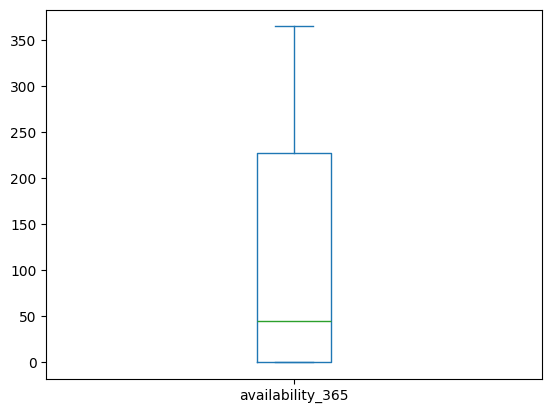

In [ ]:
df['availability_365'].plot(kind='box')

In [ ]:
Q1 = df['availability_365'].quantile(0.25)
Q3 = df['availability_365'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f'Q1 = {Q1}')
print(f'Q3 = {Q3}')
print(f'IQR = {IQR}')
print(f'Lower Bound = {lower_bound}')
print(f'Upper Bound = {upper_bound}')

print(f'Lower Outliers = {df[df["availability_365"] < lower_bound].shape[0]}')
print(f'Upper Outliers = {df[df["availability_365"] > upper_bound].shape[0]}')

Q1 = 0.0
Q3 = 227.0
IQR = 227.0
Lower Bound = -340.5
Upper Bound = 567.5
Lower Outliers = 0
Upper Outliers = 0


# Final Assessment Summary

| Column                           | Issue Identified                                    | Cleaning Required? | Planned Cleaning Action                                                        |
| -------------------------------- | --------------------------------------------------- | ------------------ | ---------------------------------------------------------------------- |
| `name`                           | 16 missing values, 4 numeric-only titles            | Yes                | Handle missing values; review numeric-only titles                      |
| `host_name`                      | 21 missing values, a few numeric-only names         | Yes                | Handle missing values; review numeric-only names                       |
| `neighbourhood_group`            | No issues                                           | No                 | Convert to `category`                                                  |
| `neighbourhood`                  | No issues                                           | No                 | Convert to `category`                                                  |
| `latitude`                       | No issues                                           | No                 | None                                                                   |
| `longitude`                      | No issues                                           | No                 | None                                                                   |
| `room_type`                      | No issues                                           | No                 | Convert to `category`                                                  |
| `price`                          | 11 zero-priced listings; statistical upper outliers | Yes                | **Investigate zero-priced listings; retain genuine price outliers**    |
| `minimum_nights`                 | Statistical upper outliers                          | Review             | **Review extreme values; retain legitimate long-term rental listings** |
| `number_of_reviews`              | Statistical upper outliers                          | No                 | Retain                                                                 |
| `last_review`                    | Expected missing values                             | No                 | **Convert to `datetime`; retain expected missing values**              |
| `reviews_per_month`              | Expected missing values                             | No                 | Retain missing values                                                  |
| `calculated_host_listings_count` | Statistical upper outliers                          | No                 | Retain                                                                 |
| `availability_365`               | No issues                                           | No                 | None                                                                   |
